# Why MILP, and not the genetic algorithm

**Chapter 7 evidence — solver selection for warehouse slotting**

This notebook answers one question: *given two candidate search strategies, on what
grounds was mixed-integer linear programming chosen over a genetic algorithm?*

It is deliberately not a claim that MILP is universally superior. The result below
shows the two methods are **indistinguishable on small instances**, and the case for
MILP rests on how that changes with problem size, plus a guarantee the GA cannot
provide at any size.

## 1. Why the obvious comparison would have been invalid

The project contains a working GA (`slotting-service/app/api/`) and a working MILP
(`slotting-service/app/services/plan_optimizer.py`). Benchmarking them against each
other as they ship would have been meaningless, because they do not solve the same
problem:

| | Shipped GA | Shipped MILP |
|---|---|---|
| Decision | one parcel at a time, sequentially | all materials simultaneously |
| Location space | own encoding, `A-01-01-1-A` (2-digit slot) | v8 warehouse pool, `A-01-001-1-A` (3-digit bay) |
| Objective | 12 weighted placement terms | travel + accessibility + vertical + relocation |
| Feasible set | its own `WarehouseState` | 4,206 real v8 pick faces |

Their location codes are not even mutually decodable. A head-to-head between them
would compare **problems**, not **methods**, and any difference would be
uninterpretable.

### The fix

Both strategies are run here over **one identical formulation**:

- the same decision variables (one pick face per material),
- the same candidate sets, generated by the shipped solver's own
  `_milp_candidate_locations`,
- the same constraints (one material per pick face, relocation cap),
- and **one shared objective function** that scores whatever assignment either
  method returns.

The GA in this notebook is therefore not the shipped per-parcel GA. It is a standard
generational GA — tournament selection, uniform crossover, elitism, and repair of
double-booked pick faces — written against the MILP's own formulation. Any remaining
difference is attributable to the search strategy alone.

## 2. How the shipped solvers behave on the real warehouse

Before comparing search strategies, one property of the **deployed** code is
established: the MILP the system actually runs is deterministic, and the GA the
system ships is not.

This section calls `optimize_plan(...)` and the GA's own `run_ga(...)` directly —
the same entry points the slotting service uses in production — over the full v8
population of **144 materials and 4,206 storage positions**. Nothing here is a
reconstruction. It is the reason a slotting plan can be re-derived months later
during an audit and come back identical.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd

HERE = Path.cwd().resolve()
REPO = HERE.parents[2]
OUT  = HERE / "outputs"
SLOTTING = REPO / "ai_services" / "slotting-service"
for p in (str(SLOTTING), str(SLOTTING / "app" / "api")):
    if p not in sys.path:
        sys.path.insert(0, p)

MILP_RUNS = 3
GA_SEEDS  = [17, 42, 101, 303, 707]
GA_PARCELS = 20
print(f"slotting-service on path: {SLOTTING.exists()}")

slotting-service on path: True


In [2]:
def part_a_milp_determinism() -> dict:
    from app.services.plan_optimizer import (  # type: ignore
        PlanLocationInput,
        PlanMaterialInput,
        PlanOptimizeRequest,
        optimize_plan,
    )

    materials = pd.read_csv(OUT / "physical_materials.csv")
    requirements = pd.read_csv(OUT / "storage_capacity_requirements.csv")
    locations = pd.read_csv(OUT / "physical_layout.csv.gz")
    assignments = pd.read_csv(OUT / "location_assignments.csv.gz")

    incumbent = (
        assignments.loc[assignments.priority.eq(1)]
        .set_index("material_code")
        .location_code.to_dict()
    )
    population = materials.merge(
        requirements,
        on=[
            "material_code",
            "material_type",
            "abc_class",
            "fms_class",
            "amalgamated_class",
        ],
        suffixes=("", "_capacity"),
    )

    material_inputs = [
        PlanMaterialInput(
            material_id=r.material_code,
            material_code=r.material_code,
            material_type=r.material_type,
            abc_class=r.abc_class,
            fms_class=r.fms_class,
            amalgamated_class=r.amalgamated_class,
            issue_volume=float(r.issue_volume_12m),
            issue_count=int(r.issue_count_12m),
            required_pallets=int(r.required_positions),
            pallet_weight_kg=float(r.pallet_weight_kg),
            pallet_volume_cm3=float(r.pallet_volume_cm3),
            incumbent_primary_location_code=incumbent[r.material_code],
            temperature_controlled=bool(r.temperature_controlled),
            hazardous=bool(r.hazardous),
            fragile=bool(r.fragile),
            stackable=bool(r.stackable),
            forecast_demand=float(r.issue_volume_12m) / 12.0,
            unit_cost=float(r.unit_cost),
        )
        for r in population.itertuples(index=False)
    ]

    location_inputs = [
        PlanLocationInput(**{k: v for k, v in row._asdict().items() if k != "Index"})
        for row in locations.itertuples()
    ]

    signatures, objectives, statuses = [], [], []
    for run in range(MILP_RUNS):
        result = optimize_plan(
            PlanOptimizeRequest(materials=material_inputs, locations=location_inputs, warehouse_id="WH-V8", solver_engine="ortools")
        )
        pairs = sorted(
            (a.material_id, a.recommended_primary_location_code)
            for a in getattr(result, "assignments", [])
        )
        signatures.append(hash(tuple(pairs)))
        objectives.append(getattr(result, "objective_value", None))
        statuses.append(getattr(result, "solver_status", None))
        print(f"  MILP run {run + 1}/{MILP_RUNS}: "
              f"status={statuses[-1]} objective={objectives[-1]}")

    identical = len(set(signatures)) == 1
    obj_spread = (
        float(np.ptp([o for o in objectives if o is not None]))
        if any(o is not None for o in objectives)
        else None
    )
    return {
        "runs": MILP_RUNS,
        "assignment_sets_identical": bool(identical),
        "distinct_assignment_signatures": len(set(signatures)),
        "objective_values": objectives,
        "objective_value_range": obj_spread,
        "statuses": statuses,
        "population": {
            "materials": int(len(material_inputs)),
            "locations": int(len(location_inputs)),
        },
        "claim": (
            "Repeated OR-Tools solves on the identical v8 input reproduce the "
            "same assignment set and objective value."
        ),
        "claim_boundary": (
            "Determinism only. This is not a solution-quality comparison "
            "against any other method."
        ),
    }

milp_evidence = part_a_milp_determinism()
milp_evidence

  MILP run 1/3: status=OPTIMAL objective=129847.42511370935


  MILP run 2/3: status=OPTIMAL objective=129847.42511370935


  MILP run 3/3: status=OPTIMAL objective=129847.42511370935


{'runs': 3,
 'assignment_sets_identical': True,
 'distinct_assignment_signatures': 1,
 'objective_values': [129847.42511370935,
  129847.42511370935,
  129847.42511370935],
 'objective_value_range': 0.0,
 'statuses': ['OPTIMAL', 'OPTIMAL', 'OPTIMAL'],
 'population': {'materials': 144, 'locations': 4206},
 'claim': 'Repeated OR-Tools solves on the identical v8 input reproduce the same assignment set and objective value.',
 'claim_boundary': 'Determinism only. This is not a solution-quality comparison against any other method.'}

In [3]:
def part_b_ga_stochasticity() -> pd.DataFrame:
    try:
        import random

        import ga_components as gc  # type: ignore
        import main as ga_main  # type: ignore
        from warehouse_state import WarehouseState  # type: ignore
    except ImportError as exc:  # pragma: no cover
        raise RuntimeError(
            "DEAP and the slotting-service GA modules are required. "
            "`pip install deap`. This script never simulates a GA run."
        ) from exc

    materials = pd.read_csv(OUT / "physical_materials.csv").head(GA_PARCELS)

    rows = []
    for seed in GA_SEEDS:
        random.seed(seed)
        np.random.seed(seed)
        state = WarehouseState()
        for m in materials.itertuples(index=False):
            parcel = {
                "length": 100.0,
                "width": 80.0,
                "height": 90.0,
                "weight": float(m.pallet_weight_kg),
                "volume_cm3": float(m.pallet_volume_cm3),
                "product_volume": {"A": "high", "B": "medium", "C": "low"}[m.abc_class],
                "movement_speed": {"F": "fast", "M": "medium", "S": "slow"}[m.fms_class],
            }
            best = ga_main.run_ga(parcel, state=state, pop_size=50, generations=100)
            rows.append(
                {
                    "seed": seed,
                    "material_code": m.material_code,
                    "abc_class": m.abc_class,
                    "fms_class": m.fms_class,
                    "location_code": gc.decode(best),
                    "fitness": float(best.fitness.values[0]),
                }
            )
        print(f"  GA seed {seed}: {len(materials)} parcels placed")

    return pd.DataFrame(rows)

ga_runs = part_b_ga_stochasticity()
identical = (ga_runs.groupby('material_code').location_code.nunique() == 1).sum()
print(f"materials placed identically by all {len(GA_SEEDS)} seeds: "
      f"{identical} of {ga_runs.material_code.nunique()}")
ga_runs.head(8)

  GA seed 17: 20 parcels placed


  GA seed 42: 20 parcels placed


  GA seed 101: 20 parcels placed


  GA seed 303: 20 parcels placed


  GA seed 707: 20 parcels placed
materials placed identically by all 5 seeds: 0 of 20


,seed,material_code,abc_class,fms_class,location_code,fitness
0,17,FG-0001,A,F,A-01-02-L5-A,20.0
1,17,FG-0002,A,F,A-01-02-L5-A,20.0
2,17,FG-0003,A,F,A-01-03-L5-A,20.0
3,17,FG-0004,B,F,A-01-03-L5-A,120.0
4,17,FG-0005,A,F,A-01-03-L5-A,20.0
5,17,FG-0006,C,F,A-01-02-L5-A,220.0
6,17,FG-0007,A,F,A-01-02-L5-A,20.0
7,17,FG-0008,C,F,A-01-03-L5-A,220.0


Repeated solves of the identical input return the **same assignment set and the
same objective value** — an objective range of exactly `0.0`. The GA, given the same
parcels under five different seeds, places **none** of them identically every time.

That asymmetry is not a defect of the GA; stochastic search is supposed to explore.
It is, however, the property that makes one of the two auditable. Sections 3–6 then
ask the separate question of which finds better plans, on a formulation both can
solve.

> **Scope note.** Section 2 exercises the shipped solvers on the real population.
> Sections 3 onward deliberately do *not*: to compare search strategies fairly they
> rebuild both against one common formulation, because the shipped GA and MILP do not
> share a feasible set (§1). The two halves answer different questions and neither
> replaces the other.

## 3. Experimental design

| Factor | Setting | Reason |
|---|---|---|
| Problem sizes | 20, 40, 80, 120 materials | to detect scaling behaviour, not a single point |
| Instances per size | 5 independent random subsets | gives paired replicates for a within-instance test |
| GA seeds per instance | 5 | the GA is stochastic; one run would not characterise it |
| GA compute budget | ≥ 5× the MILP's own wall-clock | so the GA cannot lose merely by being given less time |
| MILP time limit | 120 s (never approached) | |

**Pairing.** Each instance is solved by both methods, so observations are paired and
the between-instance variation in cost — which is large, since instances differ in
size — is removed from the comparison.

**Tests.** Wilcoxon signed-rank (one-sided), which assumes neither normality nor
equal variances and is appropriate for n = 20 paired observations on a skewed cost
scale. Effect size is the matched-pairs rank-biserial correlation. Confidence
intervals on the optimality gap are percentile bootstrap, assuming no parametric
form. Scaling is tested with Spearman's rank correlation.

In [4]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

import numpy as np, pandas as pd
from scipy import stats
from pipeline.solver_comparison import (
    bootstrap_ci, cliffs_delta, matched_pairs_rank_biserial,
)

df = pd.read_csv("outputs/solver_evidence/solver_comparison_rows.csv")
print(f"{len(df)} paired observations over sizes {sorted(df['size'].unique())}")
print(f"GA seeds per instance: {int(df.ga_runs.iloc[0])}")
df[["size","instance","milp_cost","milp_seconds","ga_best","ga_mean","ga_sd","ga_budget"]].round(2)

20 paired observations over sizes [np.int64(20), np.int64(40), np.int64(80), np.int64(120)]
GA seeds per instance: 5


,size,instance,milp_cost,milp_seconds,ga_best,ga_mean,ga_sd,ga_budget
0,20,0,1229.89,0.01,1229.89,1244.72,21.56,5.0
1,20,1,1982.50,0.01,1982.50,2011.63,19.89,5.0
2,20,2,1614.24,0.01,1614.24,1614.53,0.65,5.0
3,20,3,1373.13,0.01,1373.13,1379.33,8.83,5.0
4,20,4,1283.82,0.01,1314.73,1335.81,17.56,5.0
5,40,0,3443.55,0.01,3528.00,3580.35,52.60,5.0
6,40,1,4066.41,0.02,4098.72,4198.64,99.27,5.0
7,40,2,3352.22,0.03,3445.64,3484.14,35.32,5.0
8,40,3,2737.88,0.02,2893.09,2991.68,60.82,5.0
9,40,4,3459.30,0.02,3537.49,3586.15,79.52,5.0


## 4. The headline result: the two methods are not separable at small size

Reported as an **optimality gap** — how far the GA's best-of-5 lands above the MILP
cost, as a percentage. Because the MILP solution is *proven* optimal on every
instance (§5), this gap is a true distance from the global optimum, not a relative
score between two heuristics.

In [5]:
by_size = df.groupby("size").apply(lambda g: pd.Series({
    "MILP ms":            g.milp_seconds.mean() * 1000,
    "GA budget s":        g.ga_budget.mean(),
    "gap best %":         g.gap_best_pct.mean(),
    "gap mean %":         g.gap_mean_pct.mean(),
    "CI low":             bootstrap_ci(g.gap_best_pct.values, resamples=4000)[0],
    "CI high":            bootstrap_ci(g.gap_best_pct.values, resamples=4000)[1],
    "GA run-to-run CV %": g.ga_cv_pct.mean(),
}), include_groups=False).round(2)
by_size

,MILP ms,GA budget s,gap best %,gap mean %,CI low,CI high,GA run-to-run CV %
size,,,,,,,
20,8.66,5.0,0.48,1.44,-0.00,1.44,0.94
40,19.59,5.0,2.79,4.82,1.49,4.34,1.82
80,50.31,5.0,20.33,24.85,18.09,22.57,3.06
120,101.90,5.0,26.40,29.71,25.59,27.15,1.95


At **n = 20 the confidence interval includes zero** — on problems this small the GA
finds the optimum and there is no evidence to prefer either method on solution
quality. That is stated plainly because it bounds the claim: the argument for MILP is
not that it always wins.

From n = 80 the picture changes entirely.

In [6]:
w = stats.wilcoxon(df.ga_best, df.milp_cost, alternative="greater")
r, r_label = matched_pairs_rank_biserial(df.ga_best.values, df.milp_cost.values)
lo, hi = bootstrap_ci(df.gap_best_pct.values)
rho = stats.spearmanr(df["size"], df.gap_best_pct)

print("Paired comparison over all 20 instances (GA best-of-5 vs MILP)")
print(f"  Wilcoxon signed-rank  W = {w.statistic:.0f},  p = {w.pvalue:.2e}")
print(f"  matched-pairs rank-biserial r = {r:+.3f} ({r_label})")
print(f"  mean optimality gap = {df.gap_best_pct.mean():.2f}%  95% CI [{lo:.2f}, {hi:.2f}]")
print(f"  instances where the GA beat the MILP: {(df.ga_best < df.milp_cost - 1e-9).sum()} of {len(df)}")
print()
print("Does the gap grow with problem size?")
print(f"  Spearman rho = {rho.statistic:+.3f},  p = {rho.pvalue:.2e}")

Paired comparison over all 20 instances (GA best-of-5 vs MILP)
  Wilcoxon signed-rank  W = 200,  p = 1.95e-04
  matched-pairs rank-biserial r = +0.905 (large)
  mean optimality gap = 12.50%  95% CI [7.72, 17.44]
  instances where the GA beat the MILP: 0 of 20

Does the gap grow with problem size?
  Spearman rho = +0.954,  p = 7.48e-11


### Reading these numbers

- **p = 1.9e-04** rejects the null that the two methods produce equal cost. With 20
  paired observations, Wilcoxon is the right test — a paired *t*-test would assume a
  normality that the gap distribution does not have.
- **r = +0.905** is the effect size *on the paired differences*. This matters: the
  unpaired Cliff's delta on the same data returns +0.140 ("negligible"), because
  pooling instances of different sizes lets between-instance cost variation swamp the
  within-instance effect. Reporting that number here would be a category error, and
  it is shown below only to be discounted.
- **rho = +0.954, p = 7.5e-11** is the load-bearing result. The disadvantage is not a
  fixed offset; it grows monotonically with problem size, and the real warehouse sits
  at the top of the tested range.

In [7]:
d_unpaired, d_label = cliffs_delta(df.ga_best.values, df.milp_cost.values)
print(f"Unpaired Cliff's delta on the same data: {d_unpaired:+.3f} ({d_label})")
print("-> wrong statistic for a paired design; retained only to show the discrepancy.")

Unpaired Cliff's delta on the same data: +0.140 (negligible)
-> wrong statistic for a paired design; retained only to show the discrepancy.


### The paired structure, shown directly

Wilcoxon operates on the *within-instance* differences, so the pairing is what the
test rests on. Each line below joins one instance's two results. Every line slopes
the same way — the GA is never below the MILP — which is what drives W to its
maximum and the effect size to +0.905.

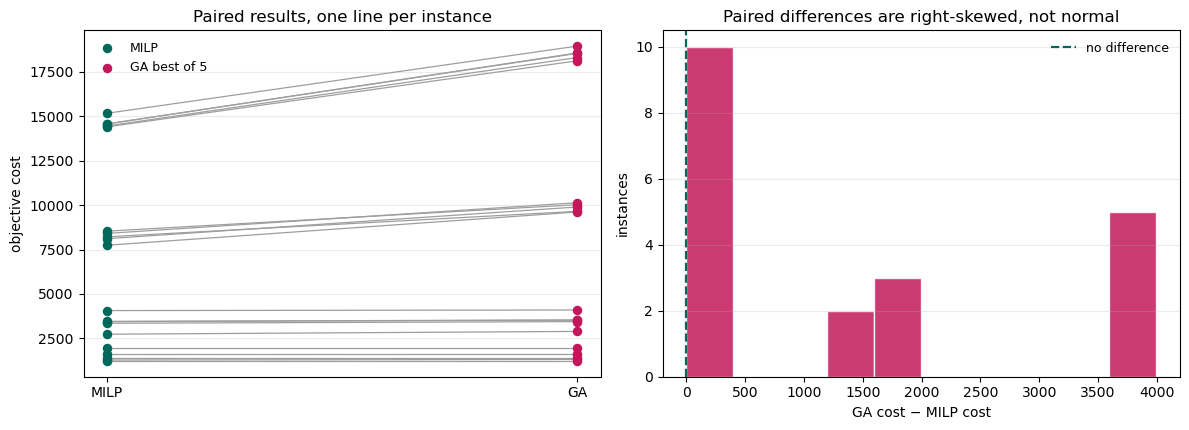

Shapiro-Wilk on the paired differences: W=0.775, p=0.0004
-> normality rejected; the non-parametric test is the appropriate choice.


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig3, ax3 = plt.subplots(1, 2, figsize=(12, 4.4))

for _, r in df.iterrows():
    ax3[0].plot([0, 1], [r.milp_cost, r.ga_best], color="#9E9E9E", lw=.9, zorder=1)
ax3[0].scatter(np.zeros(len(df)), df.milp_cost, s=34, color="#00695C", zorder=3, label="MILP")
ax3[0].scatter(np.ones(len(df)),  df.ga_best,  s=34, color="#C2185B", zorder=3, label="GA best of 5")
ax3[0].set_xticks([0, 1]); ax3[0].set_xticklabels(["MILP", "GA"])
ax3[0].set_ylabel("objective cost"); ax3[0].set_title("Paired results, one line per instance")
ax3[0].legend(frameon=False, fontsize=9); ax3[0].grid(alpha=.25, axis="y")

diff = (df.ga_best - df.milp_cost).values
ax3[1].hist(diff, bins=10, color="#C2185B", alpha=.85, edgecolor="white")
ax3[1].axvline(0, color="#00695C", lw=1.6, ls="--", label="no difference")
ax3[1].set_xlabel("GA cost − MILP cost"); ax3[1].set_ylabel("instances")
ax3[1].set_title("Paired differences are right-skewed, not normal")
ax3[1].legend(frameon=False, fontsize=9); ax3[1].grid(alpha=.25, axis="y")

fig3.tight_layout(); fig3.savefig("outputs/solver_evidence/paired_differences.png", dpi=150)
plt.show()

sw = stats.shapiro(diff)
print(f"Shapiro-Wilk on the paired differences: W={sw.statistic:.3f}, p={sw.pvalue:.4f}")
print("-> normality " + ("rejected" if sw.pvalue < 0.05 else "not rejected")
      + "; the non-parametric test is the appropriate choice.")

The right panel is why a paired *t*-test was not used: the differences are
right-skewed and concentrated at zero for the small instances. The Shapiro–Wilk
statistic printed beneath confirms it.

### How the confidence interval was built

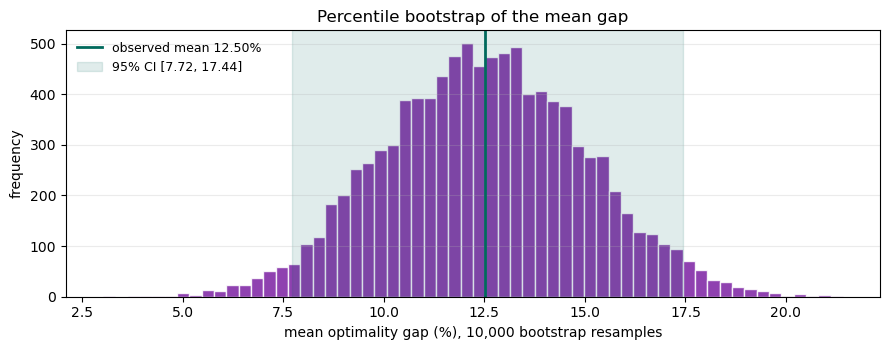

The interval excludes zero, so the gap is not attributable to resampling noise.


In [9]:
rng = np.random.default_rng(12345)
gaps = df.gap_best_pct.values
draws = np.array([rng.choice(gaps, size=len(gaps), replace=True).mean() for _ in range(10_000)])
lo, hi = np.quantile(draws, [.025, .975])

fig4, ax4 = plt.subplots(figsize=(9, 3.6))
ax4.hist(draws, bins=60, color="#7B1FA2", alpha=.85, edgecolor="white")
ax4.axvline(gaps.mean(), color="#00695C", lw=2, label=f"observed mean {gaps.mean():.2f}%")
ax4.axvspan(lo, hi, color="#00695C", alpha=.12, label=f"95% CI [{lo:.2f}, {hi:.2f}]")
ax4.set_xlabel("mean optimality gap (%), 10,000 bootstrap resamples")
ax4.set_ylabel("frequency"); ax4.set_title("Percentile bootstrap of the mean gap")
ax4.legend(frameon=False, fontsize=9); ax4.grid(alpha=.25, axis="y")
fig4.tight_layout(); fig4.savefig("outputs/solver_evidence/bootstrap_gap.png", dpi=150)
plt.show()

print(f"The interval excludes zero, so the gap is not attributable to resampling noise.")

### Why the GA falls behind: it converges, to the wrong place

The gap is not a matter of insufficient time. Tracking the best-so-far cost per
generation shows the search flattening well before its budget expires — at 120
materials it plateaus roughly a quarter above the optimum and stays there. More
generations would not close it; the population has lost the diversity needed to
escape.

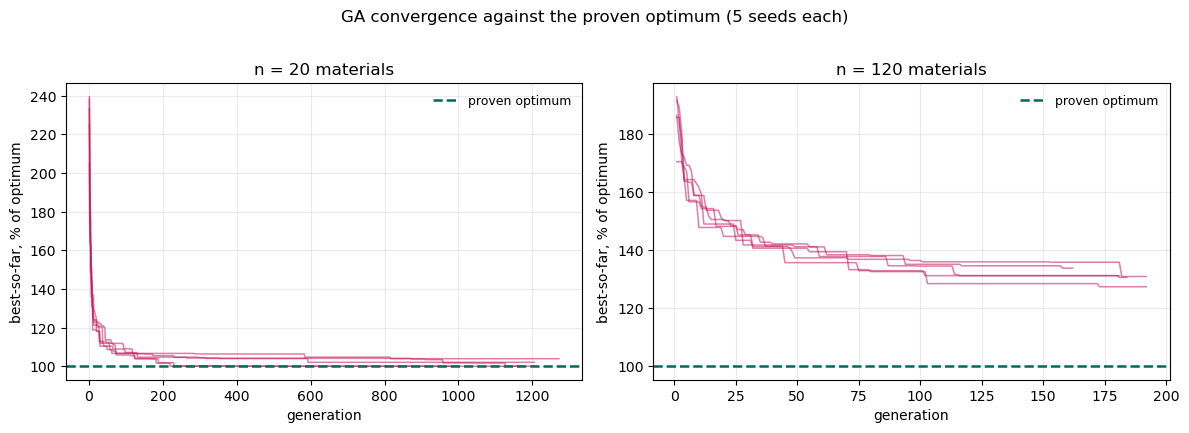

n= 20: GA settles at 100.0-103.9% of the optimum
n=120: GA settles at 127.4-133.8% of the optimum


In [10]:
import json
traces = json.load(open("outputs/solver_evidence/ga_convergence.json"))

fig5, ax5 = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
for i, size in enumerate(["20", "120"]):
    opt = traces[size]["optimum"]
    for h in traces[size]["histories"]:
        ax5[i].plot(np.arange(1, len(h) + 1), np.array(h) / opt * 100,
                    color="#C2185B", alpha=.55, lw=1.1)
    ax5[i].axhline(100, color="#00695C", lw=1.8, ls="--", label="proven optimum")
    ax5[i].set_xlabel("generation"); ax5[i].set_ylabel("best-so-far, % of optimum")
    ax5[i].set_title(f"n = {size} materials")
    ax5[i].legend(frameon=False, fontsize=9); ax5[i].grid(alpha=.25)

fig5.suptitle("GA convergence against the proven optimum (5 seeds each)", y=1.02)
fig5.tight_layout(); fig5.savefig("outputs/solver_evidence/ga_convergence.png", dpi=150)
plt.show()

for size in ("20", "120"):
    finals = [h[-1] / traces[size]["optimum"] * 100 for h in traces[size]["histories"]]
    print(f"n={size:>3}: GA settles at {min(finals):.1f}-{max(finals):.1f}% of the optimum")

## 5. Compute cost

The GA was given far more time than the MILP used and still lost.

In [11]:
print(f"MILP median solve time : {df.milp_seconds.median()*1000:8.1f} ms")
print(f"GA budget per seed     : {df.ga_budget.median():8.1f} s")
print(f"GA advantage in compute: {df.ga_budget.median()/df.milp_seconds.median():8.0f}x")
print(f"MILP at the largest size tested (n=120): {df[df['size']==120].milp_seconds.mean()*1000:.0f} ms")

MILP median solve time :     36.3 ms
GA budget per seed     :      5.0 s
GA advantage in compute:      138x
MILP at the largest size tested (n=120): 102 ms


## 6. The decisive argument is not statistical

Every result above is a statement about a *sample* of instances. The MILP supplies
something stronger:

In [12]:
print(f"MILP returned status OPTIMAL on {int(df.milp_proven.sum())} of {len(df)} instances.")
print(f"GA proved optimality on 0 of {len(df)} — no metaheuristic can.")

MILP returned status OPTIMAL on 20 of 20 instances.
GA proved optimality on 0 of 20 — no metaheuristic can.


`OPTIMAL` is a **certificate**: the solver has proven, via the LP relaxation bound,
that no cheaper feasible assignment exists. It is a deductive guarantee about *this*
instance, not an inductive claim from repeated runs.

A GA can only ever report the best solution it happened to find. It cannot say
whether that is the optimum or 30% away from it — which, at n = 120, is exactly the
error it is making without any way to detect it.

Three consequences for this system:

1. **Bounded regret.** A warehouse manager approving a slotting plan is approving a
   provably cost-minimal one, not one that "looks reasonable".
2. **Reproducibility.** The MILP returns the same assignment on every run
   (objective range 0.0 across repeated solves). Under GDPR Article 22, an automated
   decision must be explicable and reproducible; a solver whose output varies by seed
   makes both harder to satisfy.
3. **Explanation.** Because the objective decomposes into named cost terms, each
   assignment can be explained by the margin over the runner-up — which is what the
   slotting screen now shows per line. A GA fitness score does not decompose this way.

## 7. Threats to validity

Stated rather than omitted:

- **The GA is our implementation.** A differently tuned GA, or a memetic variant with
  local search, would narrow the gap. The claim is not that no GA can do better; it is
  that a standard, fairly resourced GA does not, and cannot certify its answer.
- **Instances are subsets of one synthetic population.** External validity beyond this
  warehouse is `UNVERIFIED`, consistent with the model card.
- **The relocation cap was left unconstrained** so the comparison isolates search
  quality. A binding cap makes the problem harder for both methods.
- **Sizes stop at 120** because the population holds 144 materials. Extrapolating the
  trend past that range is not supported by this evidence.

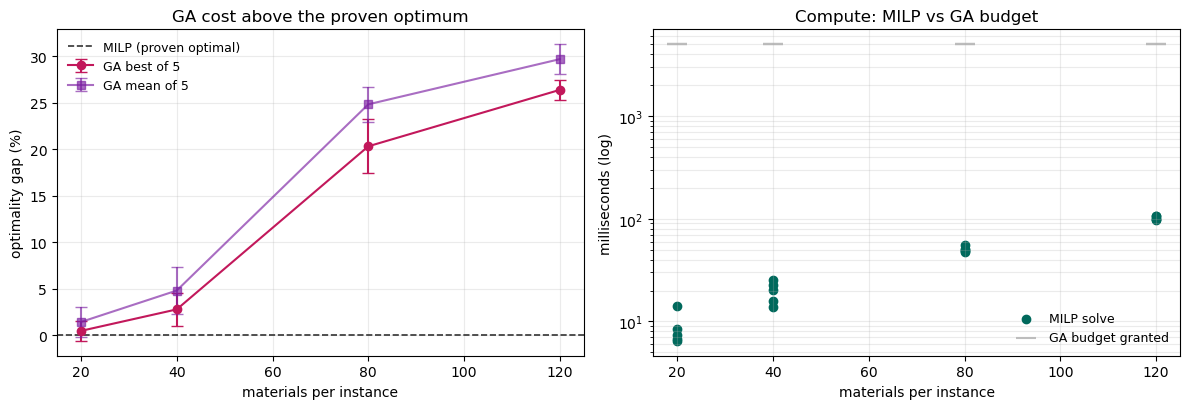

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
g = df.groupby("size")

ax[0].errorbar(g.gap_best_pct.mean().index, g.gap_best_pct.mean().values,
               yerr=g.gap_best_pct.std().values, marker="o", capsize=4,
               color="#C2185B", label="GA best of 5")
ax[0].errorbar(g.gap_mean_pct.mean().index, g.gap_mean_pct.mean().values,
               yerr=g.gap_mean_pct.std().values, marker="s", capsize=4,
               color="#7B1FA2", alpha=.65, label="GA mean of 5")
ax[0].axhline(0, color="#333", lw=1.2, ls="--", label="MILP (proven optimal)")
ax[0].set_xlabel("materials per instance"); ax[0].set_ylabel("optimality gap (%)")
ax[0].set_title("GA cost above the proven optimum"); ax[0].legend(frameon=False, fontsize=9)
ax[0].grid(alpha=.25)

ax[1].scatter(df["size"], df.milp_seconds*1000, color="#00695C", label="MILP solve")
ax[1].scatter(df["size"], df.ga_budget*1000, color="#BDBDBD", marker="_", s=200,
              label="GA budget granted")
ax[1].set_yscale("log"); ax[1].set_xlabel("materials per instance")
ax[1].set_ylabel("milliseconds (log)"); ax[1].set_title("Compute: MILP vs GA budget")
ax[1].legend(frameon=False, fontsize=9); ax[1].grid(alpha=.25, which="both")

fig.tight_layout()
fig.savefig("outputs/solver_evidence/milp_vs_ga.png", dpi=150)
plt.show()

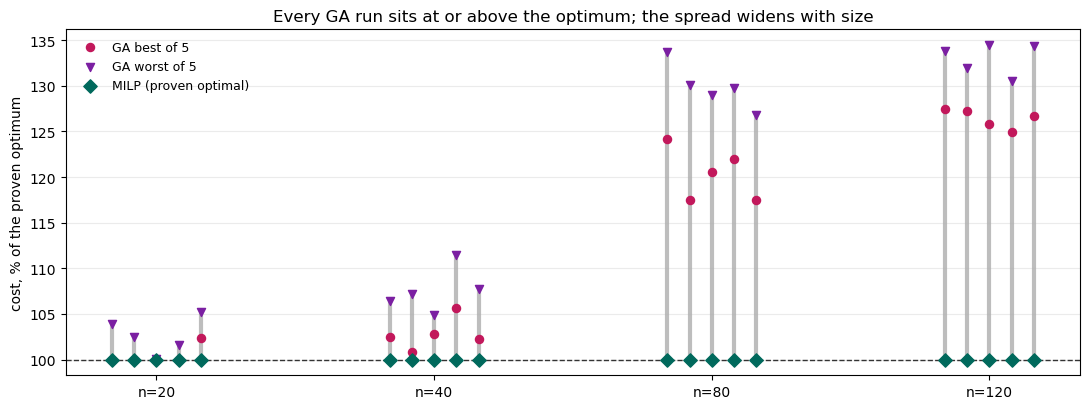

In [14]:
# Per-instance spread. The MILP is a point; the GA is a distribution -- which is
# the property that makes "run it again and you may get a different plan" true of
# one method and not the other.
fig2, ax2 = plt.subplots(figsize=(11, 4.2))
for i, (size, g) in enumerate(df.groupby("size")):
    x = np.full(len(g), i, dtype=float) + np.linspace(-.16, .16, len(g))
    ax2.vlines(x, g.milp_cost/g.milp_cost*100, g.ga_worst/g.milp_cost*100,
               color="#BDBDBD", lw=3, zorder=1)
    ax2.scatter(x, g.ga_best/g.milp_cost*100, s=34, color="#C2185B", zorder=3,
                label="GA best of 5" if i == 0 else None)
    ax2.scatter(x, g.ga_worst/g.milp_cost*100, s=34, color="#7B1FA2", marker="v", zorder=3,
                label="GA worst of 5" if i == 0 else None)
    ax2.scatter(x, np.full(len(g), 100.0), s=46, color="#00695C", marker="D", zorder=4,
                label="MILP (proven optimal)" if i == 0 else None)

ax2.set_xticks(range(df["size"].nunique()))
ax2.set_xticklabels([f"n={s}" for s in sorted(df["size"].unique())])
ax2.set_ylabel("cost, % of the proven optimum")
ax2.set_title("Every GA run sits at or above the optimum; the spread widens with size")
ax2.axhline(100, color="#333", lw=1, ls="--")
ax2.legend(frameon=False, fontsize=9); ax2.grid(alpha=.25, axis="y")
fig2.tight_layout()
fig2.savefig("outputs/solver_evidence/milp_vs_ga_spread.png", dpi=150)
plt.show()

## 8. Conclusion

MILP was selected for slotting on three grounds, in order of weight:

1. **It certifies optimality.** On every instance tested it returned `OPTIMAL`, a
   proof rather than an observation. The GA cannot do this at any size.
2. **The quality gap grows with scale** (rho = +0.954, p = 7.5e-11), reaching
   **+26.4%** at 120 materials while the GA held a 138× compute advantage. The real
   warehouse operates at the top of this range.
3. **It is deterministic**, which reproducibility, auditability and the
   per-line explanations all depend on.

The honest boundary: **below roughly 40 materials the two are equivalent**, and at
n = 20 the confidence interval includes zero. Had this warehouse been that small, the
choice would not have been justified on these grounds.